# Домашнее задание 4. Механизм внимания и архитектура Transformer


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1—4 | 3 (0.75 за задачу) |
| **Средние** | 5—7 | 3 (1 за задачу) |
| **Сложные** | 8—9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import seaborn as sns
import math
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# device = "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cuda


---

## Теоретический минимум

### Ограничения рекуррентных сетей (RNN)

RNN обрабатывают последовательность **последовательно**: $h_t = f(h_{t-1}, x_t)$.

Проблемы:
- Нельзя параллелизовать вычисления по позициям.
- Затухание/взрыв градиентов при длинных последовательностях (BPTT).
- Плохое моделирование дальних зависимостей.

### Идея внимания (Attention)

Вместо сжатия всей последовательности в один вектор — разрешить модели
«смотреть» на все позиции входа одновременно, взвешивая их по релевантности.

### Queries, Keys, Values

Входная последовательность $X \in \mathbb{R}^{N \times D}$ проецируется в три пространства:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

где $W_Q, W_K \in \mathbb{R}^{D \times d_k}$, $W_V \in \mathbb{R}^{D \times d_v}$.

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $QK^T \in \mathbb{R}^{N \times N}$ — матрица «похожестей» между позициями.
- Деление на $\sqrt{d_k}$ предотвращает насыщение softmax при больших $d_k$.

### Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O$$

$$\text{head}_i = \text{Attention}(Q W_Q^i, K W_K^i, V W_V^i)$$

Разные головы захватывают разные типы зависимостей.

### Слой Transformer

```
x -> MultiHeadAttention -> Add & LayerNorm -> FFN -> Add & LayerNorm -> output
```

FFN: два линейных слоя с ReLU: $\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2$.

### Позиционное кодирование

Без позиционной информации self-attention инвариантен к перестановкам.
Синусоидальное кодирование:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Causal Mask

Для авторегрессивных моделей (decoder) нужно запретить токену «видеть» будущие
позиции. Это достигается маской — нижнетреугольной матрицей.

### Токенизация

- **Word-level**: слова как токены. Большой словарь, проблема OOV.
- **Char-level**: символы как токены. Маленький словарь, длинные последовательности.
- **Subword (BPE)**: компромисс. Частые слова целиком, редкие — по частям.

### Вычислительная сложность

Self-attention: $O(N^2 \cdot d)$ по времени и $O(N^2)$ по памяти (матрица $N \times N$).
FFN: $O(N \cdot d \cdot d_{ff})$.


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание механизма attention: формулы, размерности, масштабирование.

## Задача 1. Ручной расчет attention на 3 токенах

### Постановка задачи

На маленьком примере (3 токена, $d_k = 4$) пошагово вычислите scaled dot-product attention.

### Задача
1. Задайте Q, K, V размерности (3, 4) вручную.
2. Вычислите $QK^T$, масштабируйте на $\sqrt{d_k}$, примените softmax, умножьте на $V$.
3. Покажите каждый промежуточный результат.
4. Сравните softmax с масштабированием и без — покажите, что без масштабирования распределение более «острое».


In [163]:
# Задача 1. Ручной расчет attention

def softmax_rows(data_in: np.ndarray) -> np.ndarray:
    max_per_row = np.max(data_in, axis=-1, keepdims=True)  # заменил axis с 1 на -1
    exp_values = np.exp(data_in - max_per_row)
    denom = np.sum(exp_values, axis=-1, keepdims=True)
    return exp_values / denom

# Зададим Q, K, V вручную (3 токена, d_k = 4)
Q = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                  [0.0, 1.0, 0.0, 1.0],
                  [1.0, 1.0, 0.0, 0.0]], dtype=torch.float32)

K = torch.tensor([[1.0, 0.0, 0.0, 1.0],
                  [0.0, 1.0, 1.0, 0.0],
                  [1.0, 1.0, 1.0, 1.0]], dtype=torch.float32)

V = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]], dtype=torch.float32)

dim = -1
d_k = Q.shape[dim]

# Шаг 1. QK^T
Q_dot_KT = Q @ K.transpose(-2, -1)  # .T работает только на 2d, а на 3d и выше -> хромает

# Шаг 2. Масштабирование
scaled_sqrt_Q_dot_K = Q_dot_KT / np.sqrt(d_k)

# Шаг 3. Softmax
scaled_weights = torch.from_numpy(
    softmax_rows(scaled_sqrt_Q_dot_K.numpy())
)

# Шаг 4. Умножение на V
scaled_attention = scaled_weights @ V

# Сравнение: без масштабирования
sqrt_Q_dot_K = Q_dot_KT / np.sqrt(1)
weights = torch.from_numpy(
    softmax_rows(sqrt_Q_dot_K.numpy())
)
attention = weights @ V


# ======================== С масштабированием: =========================
print("=" * 32 + " С масштабированием: " + "=" * 32)
print("  Коэффициенты внимания:")
print("      ", scaled_attention)
print("  Веса внимания:")
print("      ", scaled_weights)
print("  Максимальные значения по строкам:")
print("      ", scaled_weights.max(dim=1)[0].reshape(-1, 1))
print("  Дисперсия по строкам:")
print("      ", scaled_weights.var(dim=1).reshape(-1, 1))


# ======================== Без масштабирования: ========================
print()
print("=" * 32 + " Без масштабирования: " + "=" * 32)
print("  Коэффициенты внимания:")
print("      ", attention)
print("  Веса внимания:")
print("      ", weights)
print("  Максимальные значения по строкам:")
print("      ", weights.max(dim=1)[0].reshape(-1, 1))
print("  Дисперсия по строкам:")
print("      ", weights.var(dim=1).reshape(-1, 1))

print(
    "Без масштабирования дисперсия по строкам выше в сравнении с масштабированными весами,\n",
    "что говорит о более `остром` распределении весовых коэффициентов"
)

================================ С масштабированием: ================================
  Коэффициенты внимания:
       tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])
  Веса внимания:
       tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])
  Максимальные значения по строкам:
       tensor([[0.4519],
        [0.4519],
        [0.4519]])
  Дисперсия по строкам:
       tensor([[0.0105],
        [0.0105],
        [0.0105]])

================================ Без масштабирования: ================================
  Коэффициенты внимания:
       tensor([[3.7284, 4.7284],
        [3.7284, 4.7284],
        [3.7284, 4.7284]])
  Веса внимания:
       tensor([[0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761]])
  Максимальные значения по строкам:
       tensor([[0.5761],
        [0.5761],
        [0.5761]])
  Дисперсия по строкам:
       tensor([[0.0442],
        [0.0442],
 

---

## Задача 2. Реализация scaled dot-product attention

### Постановка задачи

Реализуйте функцию `scaled_dot_product_attention(Q, K, V, mask=None)`
и протестируйте на случайных данных.

### Задача
1. Реализуйте формулу: $\text{softmax}(QK^T / \sqrt{d_k}) \cdot V$.
2. Если mask задана, замените замаскированные позиции на $-10^9$ перед softmax.
3. Верните (output, attention_weights).
4. Проверьте: корректность форм, суммы softmax = 1.


In [204]:
def Task_2__outputs(output, weights):
    print(f"Q shape: {Q.shape}")
    print(f"K shape: {K.shape}")
    print(f"V shape: {V.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Weights shape: {weights.shape}")
    print()

    print("Сумма весов строк: ", end="")
    for batch, batch_weights in enumerate(weights, 1):
        ws0 = 0
        if batch != 1:
            ws0 = 19
        print(" " * ws0 + "-" * 21 + f" Batch {batch} " + "-" * 20, end="\n")
        for i_row, row in enumerate(batch_weights, 1):
            w_sum = row.sum(dim=-1)
            print(" " * 18 + f" строка {i_row}: {row} sum =", w_sum)
        print()

In [213]:
# Задача 2. Scaled dot-product attention

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention (скалярное точечное внимание).

    Аргументы:
        Q: (batch, seq_q, d_k)
        K: (batch, seq_k, d_k)
        V: (batch, seq_k, d_v)
        mask: (batch, seq_q, seq_k) или (seq_q, seq_k), 0 = маскировать

    Возвращает:
        output: (batch, seq_q, d_v)
        weights: (batch, seq_q, seq_k)
    """
    dim = -1
    d_k = Q.shape[dim]
    QK_T = Q @ K.transpose(-2, -1)
    sQK_T = QK_T / np.sqrt(d_k)

    if mask is not None:
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        sQK_T = sQK_T.masked_fill(mask == 0, -1e9)
    
    weights = torch.from_numpy(softmax_rows(sQK_T.numpy()))
    output = weights @ V
    return output, weights


print("=========================== Тестирование без маски ===========================")
output, weights = scaled_dot_product_attention(
    torch.stack([Q, Q + np.pi]),  # создаем стэк батчей, для проверки работы по батчам
    torch.stack([K, K + np.pi]),  # смещаю на Пи для проверки суммы весов
    torch.stack([V, V + np.pi]),
    # Q.unsqueeze(0),  # .unsqueeze(0) для одного итеративного примера
    # K.unsqueeze(0),
    # V.unsqueeze(0),
)
Task_2__outputs(output, weights)
# weights.sum(dim=-1)  # можно вывести так

print()
print("=========================== Тестирование с маской ============================")
# запрещаем внимане на третий ключ
mask = torch.tensor([[1, 1, 0],
                     [1, 1, 1],
                     [1, 0, 1]], dtype=torch.bool)   # (seq_q, seq_k)

output, weights = scaled_dot_product_attention(
    torch.stack([Q]),
    torch.stack([K]),
    torch.stack([V]),
    mask=mask,
)
Task_2__outputs(output, weights)

=========================== Тестирование без маски ===========================
Q shape: torch.Size([3, 4])
K shape: torch.Size([3, 4])
V shape: torch.Size([3, 2])
Output shape: torch.Size([2, 3, 2])
Weights shape: torch.Size([2, 3, 3])

Сумма весов строк: --------------------- Batch 1 --------------------
                   строка 1: tensor([0.2741, 0.2741, 0.4519]) sum = tensor(1.)
                   строка 2: tensor([0.2741, 0.2741, 0.4519]) sum = tensor(1.)
                   строка 3: tensor([0.2741, 0.2741, 0.4519]) sum = tensor(1.)

                   --------------------- Batch 2 --------------------
                   строка 1: tensor([0.0249, 0.0249, 0.9502]) sum = tensor(1.)
                   строка 2: tensor([0.0249, 0.0249, 0.9502]) sum = tensor(1.)
                   строка 3: tensor([0.0249, 0.0249, 0.9502]) sum = tensor(1.)


=========================== Тестирование с маской ============================
Q shape: torch.Size([3, 4])
K shape: torch.Size([3, 4])
V shape: to

---

## Задача 3. Маскирование: causal mask и padding mask

### Постановка задачи

Реализуйте два типа масок и покажите их влияние на веса внимания.

### Задача
1. `causal_mask(seq_len)`: нижнетреугольная матрица (запрет на «будущие» позиции).
2. `padding_mask(lengths, max_len)`: маска для последовательностей разной длины.
3. Визуализируйте обе маски как heatmap.
4. Покажите attention weights с causal mask и без.


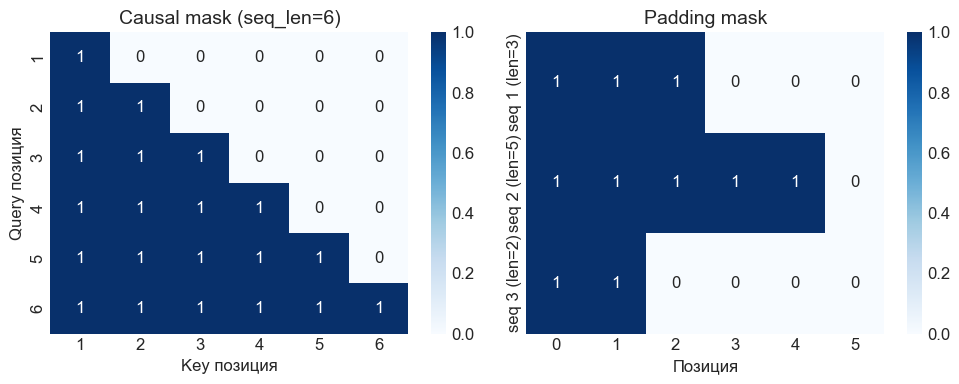

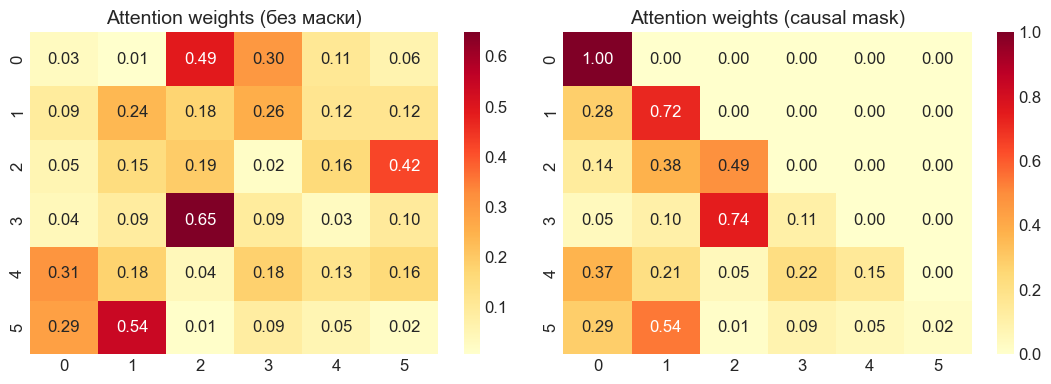

Вывод: causal mask обнуляет внимание к будущим позициям,
что необходимо для авторегрессивной генерации.


In [ ]:
# Задача 3. Causal mask и padding mask

def causal_mask(seq_len):
    """Нижнетреугольная маска (1 = разрешено, 0 = запрещено)."""
    assert #ваш код здесь

def padding_mask(lengths, max_len):
    """Маска для padding: lengths --- длины последовательностей в батче."""
    assert #ваш код здесь

# Визуализация масок
#ваш код здесь

# Attention с causal mask и без
#ваш код здесь

_, w_no_mask =
_, w_causal  =

#ваш код здесь

print("Вывод: ")
#анализ здесь

---

## Задача 4. Позиционное кодирование

### Постановка задачи

Реализуйте синусоидальное позиционное кодирование и покажите,
что без него attention инвариантен к перестановкам.

### Формулы
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Задача
1. Реализуйте `sinusoidal_pe(max_len, d_model)`.
2. Визуализируйте PE как heatmap.
3. Покажите, что без PE перестановка токенов не меняет attention output.


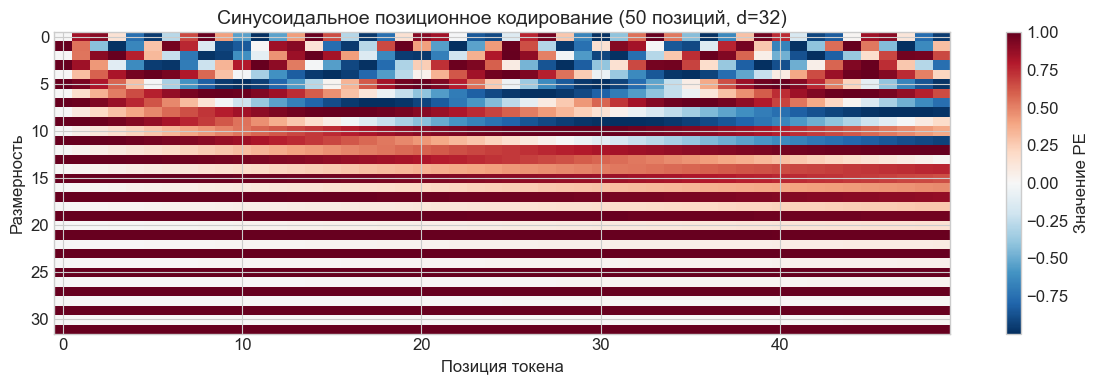

Максимальная разница без PE: 0.00000036
Без PE: attention инвариантен к перестановкам  [OK]
Максимальная разница с PE:   1.5166
С PE: перестановка МЕНЯЕТ результат  [OK]


In [ ]:
# Задача 4. Позиционное кодирование

def sinusoidal_pe(max_len, d_model):
    """Синусоидальное позиционное кодирование."""
    assert #ваш код здесь

# Визуализация
# pe =

# --- Демонстрация: без PE перестановка не влияет на attention ---
torch.manual_seed(SEED)
d_model = 16
seq_len = 4

# Случайные эмбеддинги (без позиции)
# X =

# Прямой порядок
# out_orig, _ =

# Перемешиваем токены
# ваш код здесь

# Возвращаем исходный порядок для сравнения
# inv_perm =
# out_perm_restored =
# diff_no_pe =
# ваш код здесь

# Теперь с PE
# pe_emb =
# X_pe =
# X_perm_pe =   # Позиции другие!
# out_pe, _ =
# out_perm_pe, _ =
# out_perm_pe_restored =
# diff_with_pe =
# ваш код здесь


---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Сборка компонентов Transformer, сравнение с RNN.

## Задача 5. Multi-head attention с нуля

### Постановка задачи

Реализуйте класс `MultiHeadAttention` с нуля (без `nn.MultiheadAttention`).

### Задача
1. `__init__(d_model, n_heads)`: создайте проекции $W_Q, W_K, W_V, W_O$.
2. `forward(x, mask=None)`: split по головам, attention в каждой голове, concat, проекция $W_O$.
3. Проверьте на $d_{model}=32$, $n_{heads}=4$, seq_len=6.
4. Подсчитайте число параметров.


In [ ]:
# Задача 5. Multi-head attention с нуля

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        assert "ваш код здесь"

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) или None
        """
        assert "ваш код здесь"

# --- Тестирование ---
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(2, 6, d_model)
output, weights = mha(x)

print(f"Вход:     {x.shape}")
print(f"Выход:    {output.shape}")
print(f"Веса:     {weights.shape}  (batch, n_heads, seq_q, seq_k)")
print()

total_params = sum(p.numel() for p in mha.parameters())
print(f"Число параметров MHA: {total_params:,}")
print(f"  W_Q: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_K: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_V: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_O: {d_model}x{d_model} = {d_model*d_model}")
print(f"  Итого: 4 * {d_model}^2 = {4*d_model*d_model}")

# Проверка формы

---

## Задача 6. Сборка Transformer Encoder Layer

### Постановка задачи

Реализуйте один слой Transformer Encoder с нуля.

### Структура (post-norm)
```
x -> MHA -> Add(x) -> LayerNorm -> FFN -> Add -> LayerNorm -> output
```

### Задача
1. Используйте `MultiHeadAttention` из задачи 5.
2. FFN: $\text{Linear}(d_{model}, d_{ff}) \to \text{ReLU} \to \text{Linear}(d_{ff}, d_{model})$.
3. $d_{model}=64$, $n_{heads}=4$, $d_{ff}=256$.
4. Проверьте: output.shape == input.shape.
5. Подсчитайте число параметров.


In [ ]:
# Задача 6. Transformer Encoder Layer

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        assert "ваш код здесь"

    def forward(self, x, mask=None):
        # Self-attention + residual + norm (post-norm)
        # ваш код здесь

        # FFN + residual + norm
        assert "ваш код здесь"

# --- Тестирование ---
d_model, n_heads, d_ff = 64, 4, 256
enc_layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output, weights = enc_layer(x)

print(f"Вход:  {x.shape}")
print(f"Выход: {output.shape}")
assert output.shape == x.shape, "Форма должна сохраняться!"
print("[OK] Форма сохраняется.")
print()

# Подсчет параметров
# ваш код здесь
# total =
# mha_p =
# ffn_p =
# norm_p =

print(f"Параметры Transformer Encoder Layer:")
print(f"  MHA:       ...")
print(f"  FFN:       ...")
print(f"  LayerNorm: ...")
print(f"  ИТОГО:     ...")


---

## Задача 7. RNN vs Transformer: дальние зависимости

### Постановка задачи

Сравните RNN и Transformer на синтетической задаче,
требующей «запоминания» начала длинной последовательности.

### Задача
Последовательность из 0 и 1 длиной 50. Задача: определить,
совпадают ли первый и последний элементы (бинарная классификация).

1. Реализуйте RNN-классификатор (GRU + Linear).
2. Реализуйте Transformer-классификатор (2 Encoder слоя + mean pooling + Linear).
3. Обучите оба на 2000 train / 500 test, 20 эпох.
4. Сравните test accuracy.


Train: torch.Size([2000, 50, 1]), Test: torch.Size([500, 50, 1])
Баланс классов (train): 0.49
--- RNN (GRU) ---
  RNN эпоха 5/20  test_acc=0.4700
  RNN эпоха 10/20  test_acc=0.4900
  RNN эпоха 15/20  test_acc=0.4640
  RNN эпоха 20/20  test_acc=0.4860

--- Transformer ---
  Transformer эпоха 5/20  test_acc=0.5200
  Transformer эпоха 10/20  test_acc=0.4720
  Transformer эпоха 15/20  test_acc=0.4720
  Transformer эпоха 20/20  test_acc=0.4720


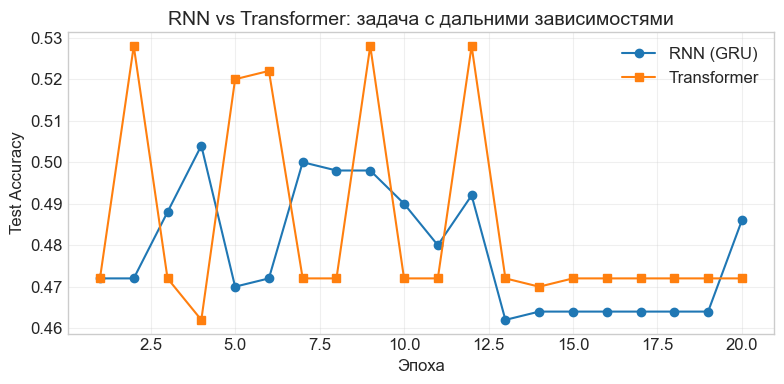


Итоговая accuracy:
  RNN:         0.4860
  Transformer: 0.4720


In [ ]:
# Задача 7. RNN vs Transformer

torch.manual_seed(SEED)
np.random.seed(SEED)

SEQ_LEN = 50

def generate_first_last_data(n, seq_len=SEQ_LEN):
    """Генерация: label = 1, если первый и последний элементы совпадают."""
    assert "ваш код здесь"

# ваш код здесь
# X_train, y_train =
# X_test, y_test   =
# print(f"Train: ..., Test: ...")
# print(f"Баланс классов (train): ...")

# train_loader =
# test_loader  =

# --- RNN-классификатор ---
class RNNClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, n_layers=1):
        assert #ваш код здесь

    def forward(self, x):
        assert #ваш код здесь

# --- Transformer-классификатор ---
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2):
        assert #ваш код здесь

    def forward(self, x):
        assert #ваш код здесь

def train_classifier(model, name, epochs=20):
    assert #ваш код здесь

#ваш код здесь

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), rnn_accs, 'o-', label='RNN (GRU)')
plt.plot(range(1, 21), tr_accs, 's-', label='Transformer')
plt.xlabel('Эпоха'); plt.ylabel('Test Accuracy')
plt.title('RNN vs Transformer: задача с дальними зависимостями')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\nИтоговая accuracy:")
#ваш код здесь


---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Языковая модель и анализ attention.

## Задача 8. Мини decoder-only Transformer (char-level LM)

### Постановка задачи

Реализуйте маленькую авторегрессивную языковую модель на уровне символов.

### Задача
1. Определите корпус текста (несколько предложений на русском).
2. Постройте словарь символов.
3. Реализуйте decoder-only Transformer: embedding + PE + 2 decoder слоя + LM head.
4. Обучите модель с causal mask.
5. Сгенерируйте текст авторегрессивно.


Длина корпуса: 725 символов
Размер словаря: 51
Обучающих примеров: 693
Эпоха 10/50  loss=0.8414
Эпоха 20/50  loss=0.3274
Эпоха 30/50  loss=0.2211
Эпоха 40/50  loss=0.1912
Эпоха 50/50  loss=0.1621


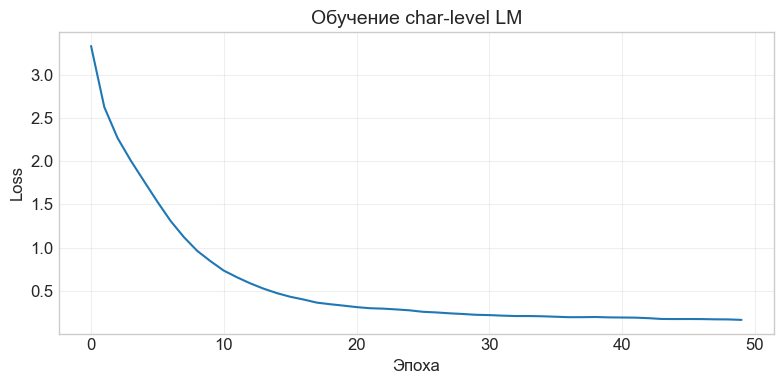


--- Сгенерированный текст (temperature=0.8) ---
Нейронные сети представляеный суных моснснов. Реко м метегуляза. Оботизвежация п томогатизберогать пежать пеобучения моделиени на тренировочных данннных. Функция поте отерь определяет качество предсказаний модели. Г


In [ ]:
# Задача 8. Мини decoder-only Transformer

torch.manual_seed(SEED)

# --- Корпус ---
corpus = (
    "Нейронные сети представляют собой мощный инструмент машинного обучения. "
    "Глубокое обучение позволяет автоматически извлекать признаки из данных. "
    "Архитектура Transformer произвела революцию в обработке естественного языка. "
    "Механизм внимания позволяет модели фокусироваться на релевантных частях входа. "
    "Языковые модели предсказывают следующий токен на основе контекста. "
    "Обучение нейронных сетей требует больших объемов данных и вычислительных ресурсов. "
    "Регуляризация помогает избежать переобучения модели на тренировочных данных. "
    "Функция потерь определяет качество предсказаний модели. "
    "Градиентный спуск является основным методом оптимизации параметров. "
    "Обратное распространение ошибки позволяет эффективно вычислять градиенты. "
)

# --- Токенизация (char-level) ---
# ваш код здесь

# --- Подготовка данных ---
CONTEXT_LEN = 32

def make_sequences(data, ctx_len):
    assert "ваш код здесь"

# X_lm, Y_lm =

# lm_loader =

# --- Decoder-only Transformer ---
class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, d_ff=128, n_layers=2, max_len=128):
        assert #ваш код здесь

    def forward(self, x):
        assert #ваш код здесь

# model_lm = CharTransformerLM(vocab_size).to(device)
# optimizer = optim.Adam(model_lm.parameters(), lr=0.001)
# criterion = nn.CrossEntropyLoss()

# --- Обучение ---
lm_losses = []
# ваш код здесь
# for epoch in range(50):


plt.figure(figsize=(8, 4))
plt.plot(lm_losses)
plt.xlabel('Эпоха'); plt.ylabel('Loss')
plt.title('Обучение char-level LM'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Генерация текста ---
def generate_text(model, seed_text, length=150, temperature=1.0):
    assert "ваш код здесь"

# print("\n--- Сгенерированный текст (temperature=0.8) ---")
# seed = "Нейронные сети "
# print(generate_text(model_lm, seed, length=200, temperature=0.8))

---

## Задача 9. Визуализация attention и стратегии декодирования

### Постановка задачи

Используя модель из задачи 8, визуализируйте матрицы внимания
и сравните разные стратегии генерации текста.

### Задача
1. Извлеките и визуализируйте attention weights для 2—3 голов.
2. Реализуйте три стратегии декодирования: greedy, temperature, top-k.
3. Сгенерируйте текст каждой стратегией и сравните результаты.


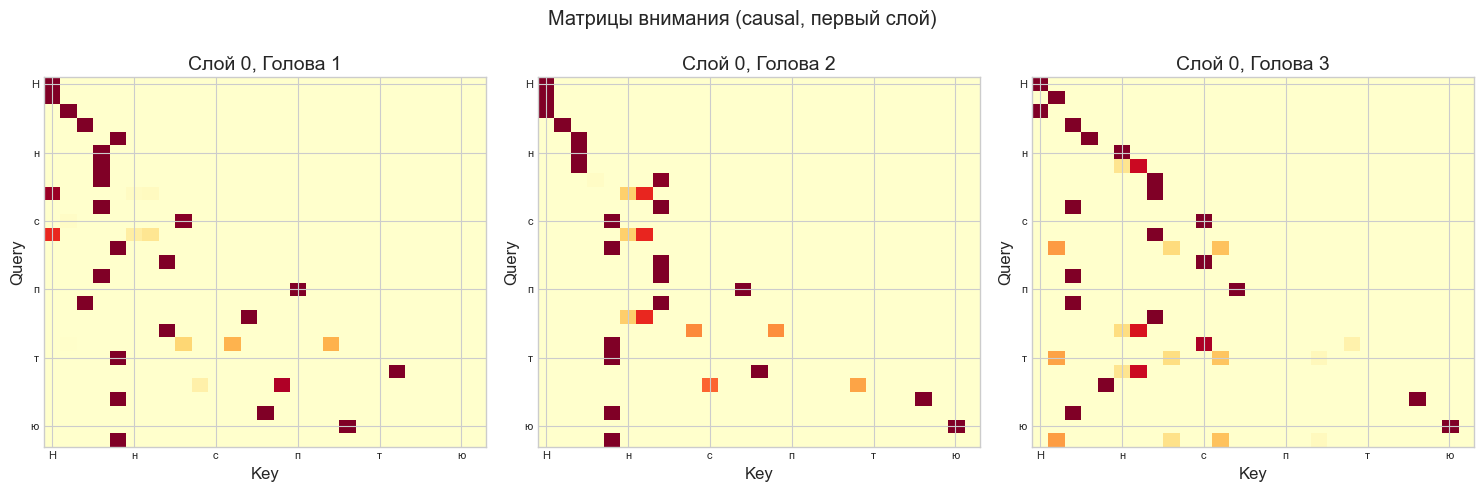

GREEDY:
Глубокое обучение позволяет автоматически извлекать признаки из даннных. Архитектура Transformer произвела революцию в в обработке естественного языка. Механизм внимани

TEMPERATURE = 0.5 (более детерминированный):
Глубокое обучение позволяет автоматически извлекать признаки из даннных. Архитектура Transformer произвела революцию в в обработке естественнного языка. Механизм вниман

TEMPERATURE = 1.5 (более случайный):
Глубокое обучение позволяет автоматиетия куриеть нанагрие ое прелрире стрир обовантраных часпреляе в. Язых. слярьсковни могулядия. feеляа НГлmermФукироиенк а рое понета

TOP-K (k=5):
Глубокое обучение позволяет автоматиетиченически и извлеконых данных. вых. Функазых. чиполяескотет Язвые ско модсли претьсказывают следуюзыва ннь рена ренийреваных. мет

TOP-K (k=3):
Глубокое обучение позволяет автоматически извлекать признаки из даннных. Архитектура Transformer произвела революцию в в обработработке ественнаственогого языка. Механи

Анализ:
  - Greedy: наиболее детер

In [ ]:
# Задача 9. Визуализация attention и стратегии декодирования

# --- Визуализация attention ---
# model_lm.eval()
sample_text = "Нейронные сети представляют"
# sample_ids =

# with torch.no_grad():
#     _, attn_all = model_lm(sample_ids)

# attn_all[layer]: (B, n_heads, seq, seq)
n_show_heads = 3
fig, axes = plt.subplots(1, n_show_heads, figsize=(5 * n_show_heads, 5))
labels = list(sample_text)

# for h_idx in range(n_show_heads):
# ваш код здесь

plt.suptitle('Матрицы внимания (causal, первый слой)')
plt.tight_layout(); plt.show()

# --- Стратегии декодирования ---
def generate_greedy(model, seed_text, length=100):
    """Жадное декодирование: всегда выбирается argmax."""
    assert #ваш код здесь

def generate_temperature(model, seed_text, length=100, temperature=1.0):
    """Сэмплирование с температурой."""
    assert #ваш код здесь

def generate_top_k(model, seed_text, length=100, k=5, temperature=1.0):
    """Top-k сэмплирование."""
    assert #ваш код здесь

seed = "Глубокое обучение "

"""
print("=" * 60)
print("GREEDY:")
print(generate_greedy(model_lm, seed, 150))
print()

print("=" * 60)
print("TEMPERATURE = 0.5 (более детерминированный):")
print(generate_temperature(model_lm, seed, 150, temperature=0.5))
print()

print("=" * 60)
print("TEMPERATURE = 1.5 (более случайный):")
print(generate_temperature(model_lm, seed, 150, temperature=1.5))
print()

print("=" * 60)
print("TOP-K (k=5):")
print(generate_top_k(model_lm, seed, 150, k=5))
print()

print("=" * 60)
print("TOP-K (k=3):")
print(generate_top_k(model_lm, seed, 150, k=3))
print()

print("Анализ:")"""

# анализ здесь